# Diffusion Model v2 per Emerging Jets

Questo notebook è una versione migliorata del primo diffusion model.

Dal run precedente abbiamo visto:

- la loss di training scendeva bene;
- il modello era stabile;
- `train vs test background AUC ≈ 0.50`, quindi ottimo controllo di domain shift;
- l'AUC background vs signal era circa `0.76`;
- i timestep medi erano i più utili (`mid-timestep AUC ≈ 0.77`);
- la logistic regression supervisionata sulle feature aggregate arrivava a circa `0.995`, quindi le feature contengono molta più informazione di quanta il diffusion score stia usando.

Quindi qui miglioriamo soprattutto **lo scoring**, più che il preprocessing.

Modifiche principali:

1. modello MLP più stabile con **LayerNorm + residual blocks**;
2. training leggermente più lungo;
3. score calcolato con più ripetizioni di rumore;
4. score separati per timestep low/mid/high;
5. nuovo **normalized denoising score**, che normalizza l'errore per timestep usando la distribuzione del train background;
6. confronto automatico tra vari score;
7. stessa diagnostica train-vs-test-background.

## 1. Import e GPU

In [1]:
from pathlib import Path
import json
import math
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
torch.manual_seed(42)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Caricamento dataset preprocessati

In [2]:
CANDIDATE_DATASETS = [
    {
        "name": "processed_flow",
        "dir": Path("processed_flow"),
        "files": {
            "val": "processed_flow_jet_track_val.npz",
            "test_background": "processed_flow_jet_track_test_background.npz",
            "test_signal": "processed_flow_jet_track_test_signal.npz",
        },
    },
    {
        "name": "processed_clean",
        "dir": Path("processed_clean"),
        "files": {
            "val": "processed_clean_jet_track_val.npz",
            "test_background": "processed_clean_jet_track_test_background.npz",
            "test_signal": "processed_clean_jet_track_test_signal.npz",
        },
    },
    {
        "name": "processed",
        "dir": Path("processed"),
        "files": {
            "val": "processed_jet_track_val.npz",
            "test_background": "processed_jet_track_test_background.npz",
            "test_signal": "processed_jet_track_test_signal.npz",
        },
    },
]

selected = None

for candidate in CANDIDATE_DATASETS:
    base = candidate["dir"]
    files = {k: base / v for k, v in candidate["files"].items()}
    ok = all(path.exists() for path in files.values())

    print(candidate["name"], "available:", ok)
    for k, path in files.items():
        print(" ", k, "->", path, "exists:", path.exists())

    if ok and selected is None:
        selected = (candidate["name"], files)

if selected is None:
    raise FileNotFoundError("Nessun dataset preprocessato trovato.")

DATASET_NAME, processed_files = selected

OUTPUT_DIR = Path("outputs_diffusion_v2")
OUTPUT_DIR.mkdir(exist_ok=True)

print("\nUsing dataset:", DATASET_NAME)
print(processed_files)

processed_flow available: True
  val -> processed_flow\processed_flow_jet_track_val.npz exists: True
  test_background -> processed_flow\processed_flow_jet_track_test_background.npz exists: True
  test_signal -> processed_flow\processed_flow_jet_track_test_signal.npz exists: True
processed_clean available: True
  val -> processed_clean\processed_clean_jet_track_val.npz exists: True
  test_background -> processed_clean\processed_clean_jet_track_test_background.npz exists: True
  test_signal -> processed_clean\processed_clean_jet_track_test_signal.npz exists: True
processed available: True
  val -> processed\processed_jet_track_val.npz exists: True
  test_background -> processed\processed_jet_track_test_background.npz exists: True
  test_signal -> processed\processed_jet_track_test_signal.npz exists: True

Using dataset: processed_flow
{'val': WindowsPath('processed_flow/processed_flow_jet_track_val.npz'), 'test_background': WindowsPath('processed_flow/processed_flow_jet_track_test_backg

## 3. Carica array

In [3]:
data_train = np.load(processed_files["val"], allow_pickle=True)
data_bg = np.load(processed_files["test_background"], allow_pickle=True)
data_sig = np.load(processed_files["test_signal"], allow_pickle=True)

X_jets_train = data_train["X_jets"].astype(np.float32)
X_tracks_train = data_train["X_tracks"].astype(np.float32)
mask_train = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

print("train:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape, mask_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

print("\nJet features:", jet_feature_names)
print("\nTrack features:", track_feature_names)

if "y" in data_train:
    print("\ntrain y:", np.unique(data_train["y"], return_counts=True))
if "meta_isDisplaced" in data_train:
    print("train meta_isDisplaced:", np.unique(data_train["meta_isDisplaced"], return_counts=True))
if "meta_isDisplaced" in data_sig:
    print("signal meta_isDisplaced:", np.unique(data_sig["meta_isDisplaced"], return_counts=True))

train: (100000, 14) (100000, 200, 12) (100000, 200)
background: (100000, 14) (100000, 200, 12) (100000, 200)
signal: (61966, 14) (61966, 200, 12) (61966, 200)

Jet features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']

Track features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']

train y: (array([0]), array([100000]))
train meta_isDisplaced: (array([0], dtype=int32), array([100000]))
signal meta_isDisplaced: (array([0, 1], dtype=int32), array([ 2322, 59644]))


## 4. Filtri

In [4]:
if "y" in data_train:
    train_filter = data_train["y"] == 0
    print("Using y == 0 for training filter.")
elif "meta_isDisplaced" in data_train:
    train_filter = data_train["meta_isDisplaced"] == 0
    print("Using meta_isDisplaced == 0 for training filter.")
else:
    train_filter = np.ones(X_jets_train.shape[0], dtype=bool)
    print("No train labels found: using all training jets.")

EVAL_ONLY_TRUE_DISPLACED_SIGNAL = True

if EVAL_ONLY_TRUE_DISPLACED_SIGNAL and "meta_isDisplaced" in data_sig:
    sig_filter = data_sig["meta_isDisplaced"] == 1
    print("Using only true displaced signal jets.")
else:
    sig_filter = np.ones(X_jets_sig.shape[0], dtype=bool)
    print("Using all signal jets.")

train_nonempty = mask_train.sum(axis=1) > 0
bg_nonempty = mask_bg.sum(axis=1) > 0
sig_nonempty = mask_sig.sum(axis=1) > 0

print("\nZero-track jets:")
print("train:", np.sum(~train_nonempty), "/", len(train_nonempty))
print("background:", np.sum(~bg_nonempty), "/", len(bg_nonempty))
print("signal:", np.sum(~sig_nonempty), "/", len(sig_nonempty))

train_filter = train_filter & train_nonempty
bg_filter = bg_nonempty
sig_filter = sig_filter & sig_nonempty

X_jets_train = X_jets_train[train_filter]
X_tracks_train = X_tracks_train[train_filter]
mask_train = mask_train[train_filter]

X_jets_bg = X_jets_bg[bg_filter]
X_tracks_bg = X_tracks_bg[bg_filter]
mask_bg = mask_bg[bg_filter]

X_jets_sig = X_jets_sig[sig_filter]
X_tracks_sig = X_tracks_sig[sig_filter]
mask_sig = mask_sig[sig_filter]

print("\nAfter filters:")
print("train:", X_jets_train.shape, X_tracks_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape)

Using y == 0 for training filter.
Using only true displaced signal jets.

Zero-track jets:
train: 0 / 100000
background: 0 / 100000
signal: 1 / 61966

After filters:
train: (100000, 14) (100000, 200, 12)
background: (100000, 14) (100000, 200, 12)
signal: (59643, 14) (59643, 200, 12)


## 5. Feature aggregate

In [5]:
def aggregate_track_features(X_tracks, mask):
    features = []

    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)


def build_aggregate_matrix(X_jets, X_tracks, mask, use_jets=True, use_tracks=True):
    parts = []
    if use_jets:
        parts.append(X_jets.astype(np.float32))
    if use_tracks:
        parts.append(aggregate_track_features(X_tracks, mask))
    return np.concatenate(parts, axis=1).astype(np.float32)


def build_aggregate_feature_names(jet_feature_names, track_feature_names, use_jets=True, use_tracks=True):
    names = []
    if use_jets:
        names.extend(jet_feature_names)
    if use_tracks:
        names.append("n_valid_tracks")
        for feat in track_feature_names:
            names.extend([
                f"{feat}_mean",
                f"{feat}_std",
                f"{feat}_median",
                f"{feat}_q90",
                f"{feat}_max",
            ])
    return names


USE_JET_FEATURES = True
USE_TRACK_AGGREGATES = True

A_train = build_aggregate_matrix(X_jets_train, X_tracks_train, mask_train, USE_JET_FEATURES, USE_TRACK_AGGREGATES)
A_bg = build_aggregate_matrix(X_jets_bg, X_tracks_bg, mask_bg, USE_JET_FEATURES, USE_TRACK_AGGREGATES)
A_sig = build_aggregate_matrix(X_jets_sig, X_tracks_sig, mask_sig, USE_JET_FEATURES, USE_TRACK_AGGREGATES)

aggregate_feature_names = build_aggregate_feature_names(
    jet_feature_names,
    track_feature_names,
    USE_JET_FEATURES,
    USE_TRACK_AGGREGATES,
)

print("A_train:", A_train.shape)
print("A_bg:", A_bg.shape)
print("A_sig:", A_sig.shape)
print("n aggregate names:", len(aggregate_feature_names))
print("finite:", np.isfinite(A_train).all(), np.isfinite(A_bg).all(), np.isfinite(A_sig).all())

A_train: (100000, 75)
A_bg: (100000, 75)
A_sig: (59643, 75)
n aggregate names: 75
finite: True True True


## 6. Robust scaling + clipping

In [6]:
ROBUST_SCALE = True
CLIP_VALUE = 8.0

if ROBUST_SCALE:
    center = np.median(A_train, axis=0, keepdims=True)
    q25 = np.percentile(A_train, 25, axis=0, keepdims=True)
    q75 = np.percentile(A_train, 75, axis=0, keepdims=True)
    scale = np.maximum(q75 - q25, 1e-6)
else:
    center = A_train.mean(axis=0, keepdims=True)
    scale = np.maximum(A_train.std(axis=0, keepdims=True), 1e-6)

A_train_norm = ((A_train - center) / scale).astype(np.float32)
A_bg_norm = ((A_bg - center) / scale).astype(np.float32)
A_sig_norm = ((A_sig - center) / scale).astype(np.float32)

A_train_norm = np.nan_to_num(A_train_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_bg_norm = np.nan_to_num(A_bg_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_sig_norm = np.nan_to_num(A_sig_norm, nan=0.0, posinf=0.0, neginf=0.0)

A_train_norm = np.clip(A_train_norm, -CLIP_VALUE, CLIP_VALUE).astype(np.float32)
A_bg_norm = np.clip(A_bg_norm, -CLIP_VALUE, CLIP_VALUE).astype(np.float32)
A_sig_norm = np.clip(A_sig_norm, -CLIP_VALUE, CLIP_VALUE).astype(np.float32)

input_dim = A_train_norm.shape[1]

print("input_dim:", input_dim)
print("A_train_norm mean/std:", A_train_norm.mean(), A_train_norm.std())
print("A_bg_norm mean/std:", A_bg_norm.mean(), A_bg_norm.std())
print("A_sig_norm mean/std:", A_sig_norm.mean(), A_sig_norm.std())

print("\nClipped fractions:")
print("train:", np.mean((A_train_norm <= -CLIP_VALUE) | (A_train_norm >= CLIP_VALUE)))
print("background:", np.mean((A_bg_norm <= -CLIP_VALUE) | (A_bg_norm >= CLIP_VALUE)))
print("signal:", np.mean((A_sig_norm <= -CLIP_VALUE) | (A_sig_norm >= CLIP_VALUE)))

input_dim: 75
A_train_norm mean/std: 0.010325394 1.2069412
A_bg_norm mean/std: 0.012264134 1.2093059
A_sig_norm mean/std: -0.09845823 1.8232726

Clipped fractions:
train: 0.012047733333333333
background: 0.012063333333333334
signal: 0.031947420485220396


## 7. Diagnostiche iniziali

In [7]:
def single_feature_auc_table(A_bg_norm, A_sig_norm, feature_names):
    rows = []
    y = np.concatenate([
        np.zeros(A_bg_norm.shape[0], dtype=np.int64),
        np.ones(A_sig_norm.shape[0], dtype=np.int64),
    ])

    for i, name in enumerate(feature_names):
        x = np.concatenate([A_bg_norm[:, i], A_sig_norm[:, i]])
        auc = roc_auc_score(y, x)
        auc_inv = roc_auc_score(y, -x)
        rows.append({
            "index": i,
            "feature": name,
            "auc": auc,
            "auc_inverted": auc_inv,
            "best_auc": max(auc, auc_inv),
        })

    return sorted(rows, key=lambda r: r["best_auc"], reverse=True)


feature_auc_rows = single_feature_auc_table(A_bg_norm, A_sig_norm, aggregate_feature_names)

print("Top 30 single-feature AUC:")
for r in feature_auc_rows[:30]:
    print(f"{r['index']:3d} {r['feature']:45s} best_auc={r['best_auc']:.4f} auc={r['auc']:.4f} inv={r['auc_inverted']:.4f}")

X_clf = np.concatenate([A_bg_norm, A_sig_norm], axis=0)
y_clf = np.concatenate([
    np.zeros(A_bg_norm.shape[0], dtype=np.int64),
    np.ones(A_sig_norm.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]
auc_logreg = roc_auc_score(y_te, proba)

print("\nSupervised logistic regression AUC:", auc_logreg)

Top 30 single-feature AUC:
 70 numberOfSCTSharedHits_mean                    best_auc=0.8812 auc=0.1188 inv=0.8812
  8 Tau2_clusterSoftDrop                          best_auc=0.8802 auc=0.8802 inv=0.1198
 71 numberOfSCTSharedHits_std                     best_auc=0.8631 auc=0.1369 inv=0.8631
 60 numberOfInnermostPixelLayerHits_mean          best_auc=0.8627 auc=0.1373 inv=0.8627
  9 Tau3_clusterSoftDrop                          best_auc=0.8621 auc=0.8621 inv=0.1379
  7 Tau1_clusterSoftDrop                          best_auc=0.8612 auc=0.8612 inv=0.1388
 45 numberOfPixelHits_mean                        best_auc=0.8453 auc=0.1547 inv=0.8453
 42 radiusOfFirstHit_median                       best_auc=0.8328 auc=0.8328 inv=0.1672
 73 numberOfSCTSharedHits_q90                     best_auc=0.8281 auc=0.1719 inv=0.8281
 40 radiusOfFirstHit_mean                         best_auc=0.8249 auc=0.8249 inv=0.1751
  5 C2_clusterSoftDrop                            best_auc=0.8220 auc=0.8220 inv=0.1780
 36 p

## 8. Dataset PyTorch

In [8]:
class DiffusionDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


full_dataset = DiffusionDataset(A_train_norm)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 1024

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 80000
Validation: 20000


## 9. Diffusion schedule

In [9]:
T = 200

beta_start = 1e-4
beta_end = 2e-2

betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

betas = betas.to(device)
alphas = alphas.to(device)
alpha_bars = alpha_bars.to(device)

# SNR è utile per pesare o interpretare timestep.
snr = alpha_bars / (1.0 - alpha_bars)

print("T:", T)
print("alpha_bar first/last:", alpha_bars[0].item(), alpha_bars[-1].item())
print("SNR first/last:", snr[0].item(), snr[-1].item())


def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    a_bar = alpha_bars[t].unsqueeze(1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise
    return xt, noise

T: 200
alpha_bar first/last: 0.9998999834060669 0.1321827620267868
SNR first/last: 9997.3408203125 0.1523163616657257


## 10. Modello migliorato: residual MLP denoiser

In [10]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.emb_dim = emb_dim

    def forward(self, t):
        half_dim = self.emb_dim // 2
        device_t = t.device

        freqs = torch.exp(
            -math.log(10000) * torch.arange(0, half_dim, device=device_t).float() / max(half_dim - 1, 1)
        )

        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)

        if self.emb_dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)

        return emb


class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.05):
        super().__init__()

        self.block = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, x):
        return x + self.block(x)


class ResidualTabularDenoiser(nn.Module):
    def __init__(self, input_dim, time_emb_dim=64, hidden_dim=384, n_blocks=4, dropout=0.05):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_emb_dim)

        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, dropout=dropout)
            for _ in range(n_blocks)
        ])

        self.output = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, xt, t):
        t_h = self.time_mlp(self.time_embedding(t))
        h = self.input_proj(xt) + t_h

        for block in self.blocks:
            h = block(h)

        return self.output(h)

## 11. Crea modello

In [11]:
time_emb_dim = 64
hidden_dim = 384
n_blocks = 4
dropout = 0.05
learning_rate = 1e-4

model = ResidualTabularDenoiser(
    input_dim=input_dim,
    time_emb_dim=time_emb_dim,
    hidden_dim=hidden_dim,
    n_blocks=n_blocks,
    dropout=dropout,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=6,
)

print(model)
print("input_dim:", input_dim)
print("time_emb_dim:", time_emb_dim)
print("hidden_dim:", hidden_dim)
print("n_blocks:", n_blocks)
print("learning_rate:", learning_rate)

ResidualTabularDenoiser(
  (time_embedding): SinusoidalTimeEmbedding()
  (time_mlp): Sequential(
    (0): Linear(in_features=64, out_features=384, bias=True)
    (1): SiLU()
    (2): Linear(in_features=384, out_features=384, bias=True)
  )
  (input_proj): Linear(in_features=75, out_features=384, bias=True)
  (blocks): ModuleList(
    (0-3): 4 x ResidualBlock(
      (block): Sequential(
        (0): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
        (1): SiLU()
        (2): Linear(in_features=384, out_features=384, bias=True)
        (3): Dropout(p=0.05, inplace=False)
        (4): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
        (5): SiLU()
        (6): Linear(in_features=384, out_features=384, bias=True)
      )
    )
  )
  (output): Sequential(
    (0): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): SiLU()
    (2): Linear(in_features=384, out_features=75, bias=True)
  )
)
input_dim: 75
time_emb_dim: 64
hidden_di

## 12. Training

In [12]:
def diffusion_loss(model, x0):
    B = x0.shape[0]
    t = torch.randint(0, T, (B,), device=x0.device, dtype=torch.long)
    noise = torch.randn_like(x0)

    xt, noise = q_sample(x0, t, noise=noise)
    noise_pred = model(xt, t)

    return torch.mean((noise_pred - noise) ** 2)


def evaluate_diffusion_loss(model, loader):
    model.eval()
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            loss = diffusion_loss(model, X_batch)
            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_loss / total_items


n_epochs = 120
early_stopping_patience = 18

train_loss_history = []
val_loss_history = []
lr_history = []

best_val_loss = np.inf
best_epoch = -1
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(n_epochs):
    model.train()
    total_loss = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        loss = diffusion_loss(model, X_batch)

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    train_loss = total_loss / total_items
    val_loss = evaluate_diffusion_loss(model, val_loader)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    lr_history.append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch+1:03d}/{n_epochs} | "
        f"train loss={train_loss:.6f} | "
        f"val loss={val_loss:.6f} | "
        f"best val={best_val_loss:.6f} @ epoch {best_epoch} | "
        f"lr={current_lr:.2e}"
    )

    if epochs_without_improvement >= early_stopping_patience:
        print("Early stopping.")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"Loaded best model from epoch {best_epoch} with val loss={best_val_loss:.6f}")

Epoch 001/120 | train loss=0.863011 | val loss=0.695852 | best val=0.695852 @ epoch 1 | lr=1.00e-04
Epoch 002/120 | train loss=0.630306 | val loss=0.561197 | best val=0.561197 @ epoch 2 | lr=1.00e-04
Epoch 003/120 | train loss=0.541033 | val loss=0.502369 | best val=0.502369 @ epoch 3 | lr=1.00e-04
Epoch 004/120 | train loss=0.496966 | val loss=0.473473 | best val=0.473473 @ epoch 4 | lr=1.00e-04
Epoch 005/120 | train loss=0.471916 | val loss=0.447561 | best val=0.447561 @ epoch 5 | lr=1.00e-04
Epoch 006/120 | train loss=0.452947 | val loss=0.432384 | best val=0.432384 @ epoch 6 | lr=1.00e-04
Epoch 007/120 | train loss=0.437674 | val loss=0.417865 | best val=0.417865 @ epoch 7 | lr=1.00e-04
Epoch 008/120 | train loss=0.421434 | val loss=0.405087 | best val=0.405087 @ epoch 8 | lr=1.00e-04
Epoch 009/120 | train loss=0.411421 | val loss=0.393573 | best val=0.393573 @ epoch 9 | lr=1.00e-04
Epoch 010/120 | train loss=0.402073 | val loss=0.386661 | best val=0.386661 @ epoch 10 | lr=1.00e-04

## 13. Plot training

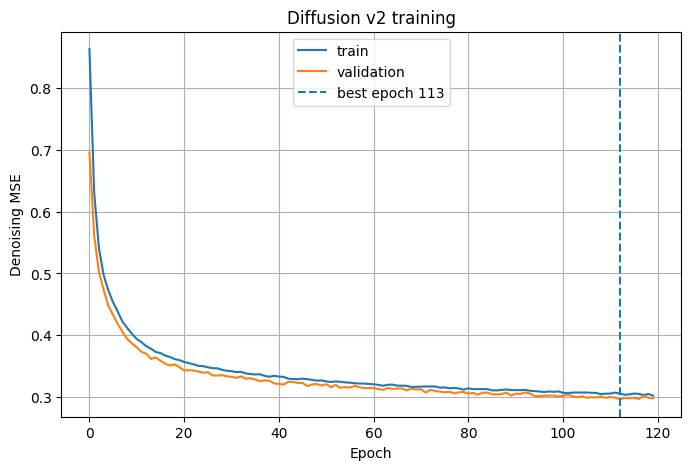

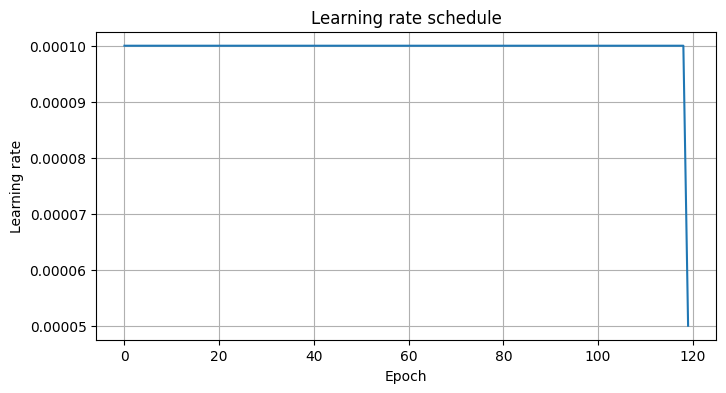

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="train")
plt.plot(val_loss_history, label="validation")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Denoising MSE")
plt.title("Diffusion v2 training")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.show()

## 14. Denoising scores per timestep

In [14]:
# Timestep scelti sulla base del run precedente:
# low era debole, mid era il più informativo, high ancora buono.
# Qui valutiamo più score e lasciamo decidere dai numeri.

timesteps_all = torch.tensor([5, 10, 20, 40, 70, 100, 140, 180], dtype=torch.long, device=device)
timesteps_low = torch.tensor([5, 10, 20], dtype=torch.long, device=device)
timesteps_mid = torch.tensor([40, 70, 100], dtype=torch.long, device=device)
timesteps_high = torch.tensor([140, 180], dtype=torch.long, device=device)
timesteps_mid_high = torch.tensor([40, 70, 100, 140, 180], dtype=torch.long, device=device)

print("timesteps_all:", timesteps_all.cpu().numpy())


def compute_per_timestep_scores(model, X, timesteps, batch_size=2048, n_noise_repeats=3):
    dataset = DiffusionDataset(X)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    model.eval()
    per_timestep_scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            B = X_batch.shape[0]

            scores_batch = []

            for t_scalar in timesteps:
                t = torch.full((B,), int(t_scalar.item()), device=device, dtype=torch.long)
                score_sum = torch.zeros(B, device=device)

                for _ in range(n_noise_repeats):
                    noise = torch.randn_like(X_batch)
                    xt, true_noise = q_sample(X_batch, t, noise=noise)
                    pred_noise = model(xt, t)
                    mse = torch.mean((pred_noise - true_noise) ** 2, dim=1)
                    score_sum += mse

                score_t = score_sum / n_noise_repeats
                scores_batch.append(score_t.unsqueeze(1))

            scores_batch = torch.cat(scores_batch, dim=1)  # (B, n_timesteps)
            per_timestep_scores.append(scores_batch.cpu().numpy())

    return np.concatenate(per_timestep_scores, axis=0)


train_scores_t = compute_per_timestep_scores(model, A_train_norm, timesteps_all, n_noise_repeats=3)
bg_scores_t = compute_per_timestep_scores(model, A_bg_norm, timesteps_all, n_noise_repeats=3)
sig_scores_t = compute_per_timestep_scores(model, A_sig_norm, timesteps_all, n_noise_repeats=3)

print("train_scores_t:", train_scores_t.shape)
print("bg_scores_t:", bg_scores_t.shape)
print("sig_scores_t:", sig_scores_t.shape)

# Raw scores
scores_train_all = train_scores_t.mean(axis=1)
scores_bg_all = bg_scores_t.mean(axis=1)
scores_sig_all = sig_scores_t.mean(axis=1)

scores_bg_low = bg_scores_t[:, [0, 1, 2]].mean(axis=1)
scores_sig_low = sig_scores_t[:, [0, 1, 2]].mean(axis=1)

scores_bg_mid = bg_scores_t[:, [3, 4, 5]].mean(axis=1)
scores_sig_mid = sig_scores_t[:, [3, 4, 5]].mean(axis=1)

scores_bg_high = bg_scores_t[:, [6, 7]].mean(axis=1)
scores_sig_high = sig_scores_t[:, [6, 7]].mean(axis=1)

scores_bg_mid_high = bg_scores_t[:, [3, 4, 5, 6, 7]].mean(axis=1)
scores_sig_mid_high = sig_scores_t[:, [3, 4, 5, 6, 7]].mean(axis=1)

# Normalized per-timestep score:
# Per ogni timestep, normalizziamo l'errore rispetto a train background.
# Serve perché la scala dell'errore può cambiare molto con t.
train_t_mean = train_scores_t.mean(axis=0, keepdims=True)
train_t_std = train_scores_t.std(axis=0, keepdims=True)
train_t_std = np.maximum(train_t_std, 1e-8)

train_scores_t_z = (train_scores_t - train_t_mean) / train_t_std
bg_scores_t_z = (bg_scores_t - train_t_mean) / train_t_std
sig_scores_t_z = (sig_scores_t - train_t_mean) / train_t_std

scores_train_z_all = train_scores_t_z.mean(axis=1)
scores_bg_z_all = bg_scores_t_z.mean(axis=1)
scores_sig_z_all = sig_scores_t_z.mean(axis=1)

scores_bg_z_mid = bg_scores_t_z[:, [3, 4, 5]].mean(axis=1)
scores_sig_z_mid = sig_scores_t_z[:, [3, 4, 5]].mean(axis=1)

scores_bg_z_mid_high = bg_scores_t_z[:, [3, 4, 5, 6, 7]].mean(axis=1)
scores_sig_z_mid_high = sig_scores_t_z[:, [3, 4, 5, 6, 7]].mean(axis=1)


def print_score_summary(name, scores):
    print("\n", name)
    print("mean:", scores.mean())
    print("std:", scores.std())
    print("median:", np.median(scores))
    print("quantiles:", np.percentile(scores, [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]))

print_score_summary("background raw all", scores_bg_all)
print_score_summary("signal raw all", scores_sig_all)
print_score_summary("background z all", scores_bg_z_all)
print_score_summary("signal z all", scores_sig_z_all)

timesteps_all: [  5  10  20  40  70 100 140 180]
train_scores_t: (100000, 8)
bg_scores_t: (100000, 8)
sig_scores_t: (59643, 8)

 background raw all
mean: 0.42723715
std: 0.038035825
median: 0.42366844
quantiles: [0.3008714  0.35674935 0.37376335 0.40169011 0.42366846 0.44858625
 0.49193415 0.53237603 0.60324418 1.48031914]

 signal raw all
mean: 0.50440824
std: 0.104343
median: 0.4915536
quantiles: [0.32619601 0.39596229 0.42043364 0.45965593 0.4915536  0.52986243
 0.60576026 0.68767838 1.88335657 2.07486486]

 background z all
mean: 0.0128869815
std: 0.63170666
median: -0.05354321
quantiles: [-1.9498105  -1.12668867 -0.86007695 -0.41538113 -0.05354321  0.36040328
  1.10402033  1.80339657  3.02583083 16.41875839]

 signal z all
mean: 1.3355641
std: 1.7191672
median: 1.1004125
quantiles: [-1.51588643 -0.45946752 -0.06839238  0.57069996  1.10041249  1.75487232
  3.1393085   4.66509704 23.33522221 27.29179382]


## 15. ROC/AUC comparison

raw all timesteps                   AUC=0.8712 AUC_inv=0.1288 best=0.8712
raw low timesteps                   AUC=0.8061 AUC_inv=0.1939 best=0.8061
raw mid timesteps                   AUC=0.8491 AUC_inv=0.1509 best=0.8491
raw high timesteps                  AUC=0.8245 AUC_inv=0.1755 best=0.8245
raw mid+high timesteps              AUC=0.8649 AUC_inv=0.1351 best=0.8649
z-normalized all timesteps          AUC=0.8764 AUC_inv=0.1236 best=0.8764
z-normalized mid timesteps          AUC=0.8498 AUC_inv=0.1502 best=0.8498
z-normalized mid+high timesteps     AUC=0.8651 AUC_inv=0.1349 best=0.8651

Best score: z_all -> (0.8763887631406871, 0.12361123685931291, 0.8763887631406871)
Best diffusion score: z_all         AUC=0.8764 AUC_inv=0.1236 best=0.8764


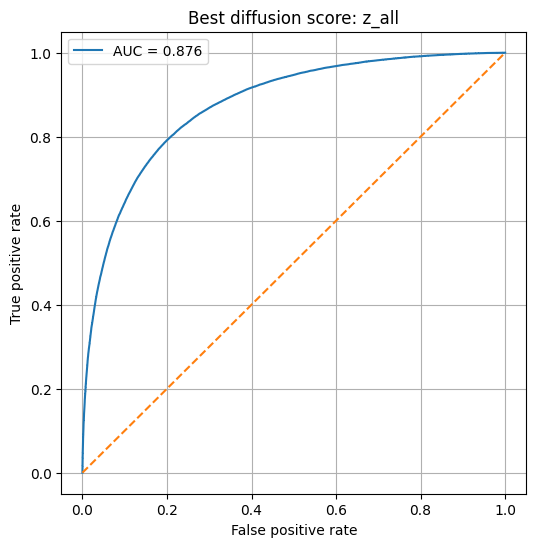

In [15]:
def evaluate_binary_scores(bg_scores, sig_scores, title, make_plot=True):
    y_true = np.concatenate([
        np.zeros_like(bg_scores),
        np.ones_like(sig_scores),
    ])

    y_score = np.concatenate([
        bg_scores,
        sig_scores,
    ])

    auc = roc_auc_score(y_true, y_score)
    auc_inv = roc_auc_score(y_true, -y_score)
    best_auc = max(auc, auc_inv)

    print(f"{title:35s} AUC={auc:.4f} AUC_inv={auc_inv:.4f} best={best_auc:.4f}")

    if make_plot:
        if auc_inv > auc:
            plot_score = -y_score
            label = f"AUC inverted = {auc_inv:.3f}"
        else:
            plot_score = y_score
            label = f"AUC = {auc:.3f}"

        fpr, tpr, _ = roc_curve(y_true, plot_score)

        plt.figure(figsize=(6, 6))
        plt.plot(fpr, tpr, label=label)
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False positive rate")
        plt.ylabel("True positive rate")
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.show()

    return auc, auc_inv, best_auc


score_results = {}

score_results["raw_all"] = evaluate_binary_scores(scores_bg_all, scores_sig_all, "raw all timesteps", make_plot=False)
score_results["raw_low"] = evaluate_binary_scores(scores_bg_low, scores_sig_low, "raw low timesteps", make_plot=False)
score_results["raw_mid"] = evaluate_binary_scores(scores_bg_mid, scores_sig_mid, "raw mid timesteps", make_plot=False)
score_results["raw_high"] = evaluate_binary_scores(scores_bg_high, scores_sig_high, "raw high timesteps", make_plot=False)
score_results["raw_mid_high"] = evaluate_binary_scores(scores_bg_mid_high, scores_sig_mid_high, "raw mid+high timesteps", make_plot=False)

score_results["z_all"] = evaluate_binary_scores(scores_bg_z_all, scores_sig_z_all, "z-normalized all timesteps", make_plot=False)
score_results["z_mid"] = evaluate_binary_scores(scores_bg_z_mid, scores_sig_z_mid, "z-normalized mid timesteps", make_plot=False)
score_results["z_mid_high"] = evaluate_binary_scores(scores_bg_z_mid_high, scores_sig_z_mid_high, "z-normalized mid+high timesteps", make_plot=False)

best_score_name = max(score_results, key=lambda k: score_results[k][2])
print("\nBest score:", best_score_name, "->", score_results[best_score_name])

# Scegli automaticamente lo score migliore per i plot principali.
if best_score_name == "raw_all":
    best_bg, best_sig, best_train = scores_bg_all, scores_sig_all, scores_train_all
elif best_score_name == "raw_low":
    best_bg, best_sig, best_train = scores_bg_low, scores_sig_low, None
elif best_score_name == "raw_mid":
    best_bg, best_sig, best_train = scores_bg_mid, scores_sig_mid, None
elif best_score_name == "raw_high":
    best_bg, best_sig, best_train = scores_bg_high, scores_sig_high, None
elif best_score_name == "raw_mid_high":
    best_bg, best_sig, best_train = scores_bg_mid_high, scores_sig_mid_high, None
elif best_score_name == "z_all":
    best_bg, best_sig, best_train = scores_bg_z_all, scores_sig_z_all, scores_train_z_all
elif best_score_name == "z_mid":
    best_bg, best_sig, best_train = scores_bg_z_mid, scores_sig_z_mid, None
elif best_score_name == "z_mid_high":
    best_bg, best_sig, best_train = scores_bg_z_mid_high, scores_sig_z_mid_high, None

best_auc_tuple = evaluate_binary_scores(best_bg, best_sig, f"Best diffusion score: {best_score_name}", make_plot=True)

## 16. Plot distributions

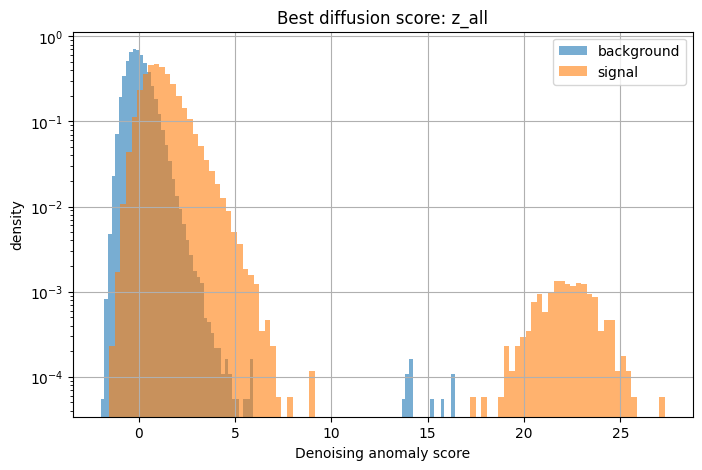

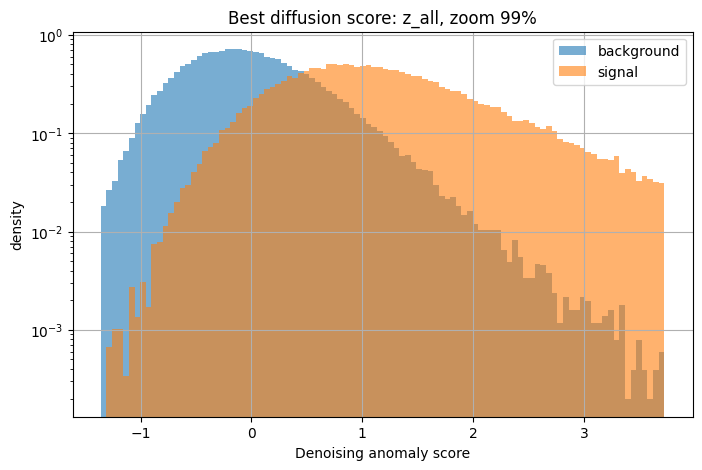

In [16]:
def plot_score_distribution(bg_scores, sig_scores, title, zoom_percentile=None):
    plt.figure(figsize=(8, 5))

    if zoom_percentile is not None:
        hi = np.percentile(np.concatenate([bg_scores, sig_scores]), zoom_percentile)
        lo = np.percentile(np.concatenate([bg_scores, sig_scores]), 0.1)
        plot_range = (lo, hi)
    else:
        plot_range = None

    plt.hist(bg_scores, bins=100, range=plot_range, density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, range=plot_range, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel("Denoising anomaly score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_score_distribution(best_bg, best_sig, f"Best diffusion score: {best_score_name}")
plot_score_distribution(best_bg, best_sig, f"Best diffusion score: {best_score_name}, zoom 99%", zoom_percentile=99)

## 17. Train vs test background

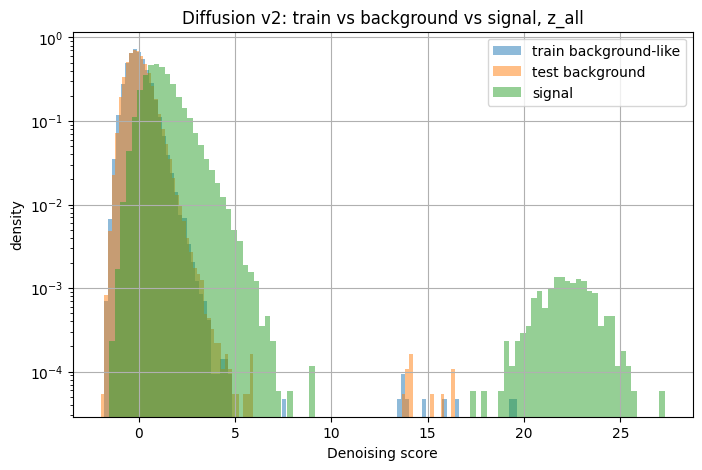

Train vs test background AUC: 0.50521284565
Train vs test background AUC inverted: 0.49478715435000004
Best train-vs-test-background AUC: 0.50521284565


In [17]:
def compare_train_bg_sig(train_scores, bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(train_scores, bins=100, density=True, alpha=0.5, label="train background-like")
    plt.hist(bg_scores, bins=100, density=True, alpha=0.5, label="test background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.5, label="signal")
    plt.yscale("log")
    plt.xlabel("Denoising score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    y = np.concatenate([
        np.zeros_like(train_scores),
        np.ones_like(bg_scores),
    ])

    s = np.concatenate([
        train_scores,
        bg_scores,
    ])

    auc_tb = roc_auc_score(y, s)
    auc_tb_inv = roc_auc_score(y, -s)
    best_auc_tb = max(auc_tb, auc_tb_inv)

    print("Train vs test background AUC:", auc_tb)
    print("Train vs test background AUC inverted:", auc_tb_inv)
    print("Best train-vs-test-background AUC:", best_auc_tb)

    return auc_tb, auc_tb_inv, best_auc_tb


# Per avere sempre train score coerente, usiamo z_all come controllo principale.
auc_train_bg, auc_train_bg_inv, best_auc_train_bg = compare_train_bg_sig(
    scores_train_z_all,
    scores_bg_z_all,
    scores_sig_z_all,
    "Diffusion v2: train vs background vs signal, z_all",
)

## 18. Track-only diagnostic

In [18]:
A_train_tracks_only = build_aggregate_matrix(X_jets_train, X_tracks_train, mask_train, use_jets=False, use_tracks=True)
A_bg_tracks_only = build_aggregate_matrix(X_jets_bg, X_tracks_bg, mask_bg, use_jets=False, use_tracks=True)
A_sig_tracks_only = build_aggregate_matrix(X_jets_sig, X_tracks_sig, mask_sig, use_jets=False, use_tracks=True)

center_to = np.median(A_train_tracks_only, axis=0, keepdims=True)
q25_to = np.percentile(A_train_tracks_only, 25, axis=0, keepdims=True)
q75_to = np.percentile(A_train_tracks_only, 75, axis=0, keepdims=True)
scale_to = np.maximum(q75_to - q25_to, 1e-6)

A_bg_tracks_only_norm = np.clip(((A_bg_tracks_only - center_to) / scale_to), -CLIP_VALUE, CLIP_VALUE).astype(np.float32)
A_sig_tracks_only_norm = np.clip(((A_sig_tracks_only - center_to) / scale_to), -CLIP_VALUE, CLIP_VALUE).astype(np.float32)

X_clf_to = np.concatenate([A_bg_tracks_only_norm, A_sig_tracks_only_norm], axis=0)
y_clf_to = np.concatenate([
    np.zeros(A_bg_tracks_only_norm.shape[0], dtype=np.int64),
    np.ones(A_sig_tracks_only_norm.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(X_clf_to, y_clf_to, test_size=0.3, random_state=42, stratify=y_clf_to)

clf_to = LogisticRegression(max_iter=3000)
clf_to.fit(X_tr, y_tr)

proba_to = clf_to.predict_proba(X_te)[:, 1]
auc_track_only_logreg = roc_auc_score(y_te, proba_to)

print("Track-only supervised logistic regression AUC:", auc_track_only_logreg)

Track-only supervised logistic regression AUC: 0.9895588349261348


## 19. Sampling sanity check

sampled shape: (5000, 75)
sampled finite: True
sampled mean/std: 0.0277636 0.76360196
sampled quantiles: [-1.38645153e+01 -1.74113783e+00 -9.97833455e-01 -3.22005868e-01
 -5.90353832e-03  3.49687397e-01  1.18255923e+00  2.07048377e+00
  1.00419827e+01]


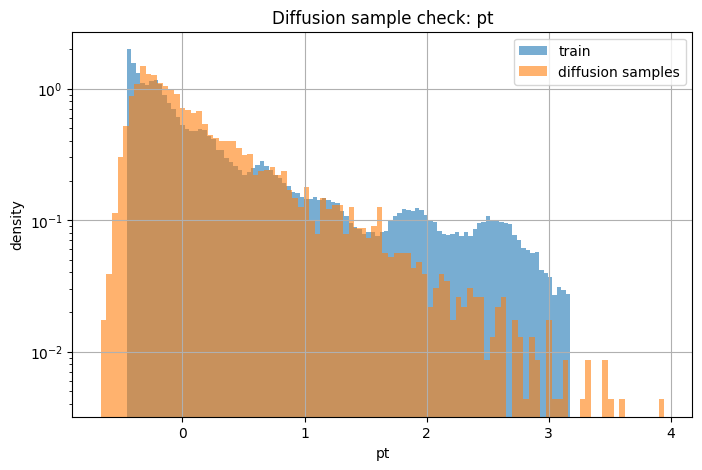

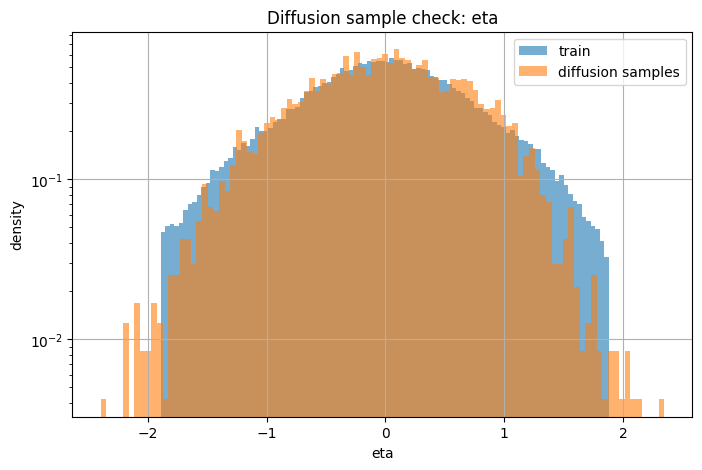

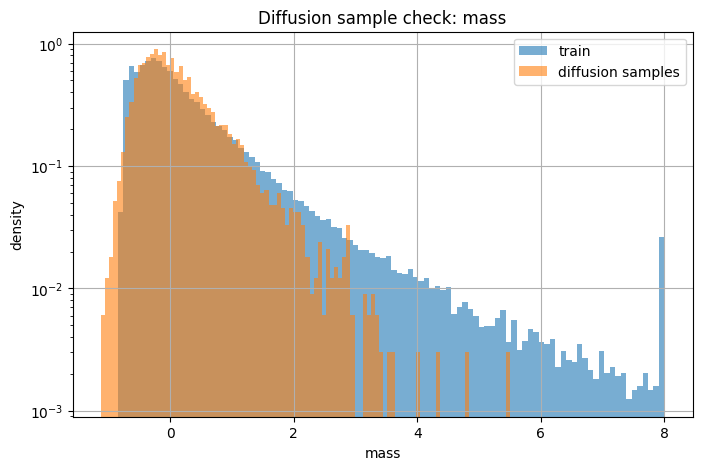

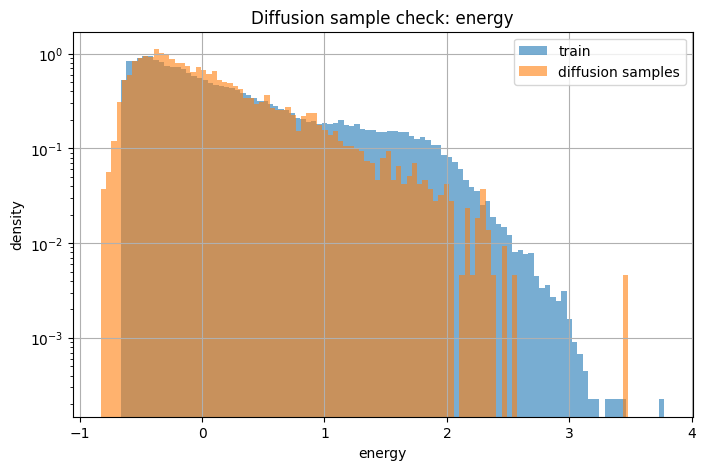

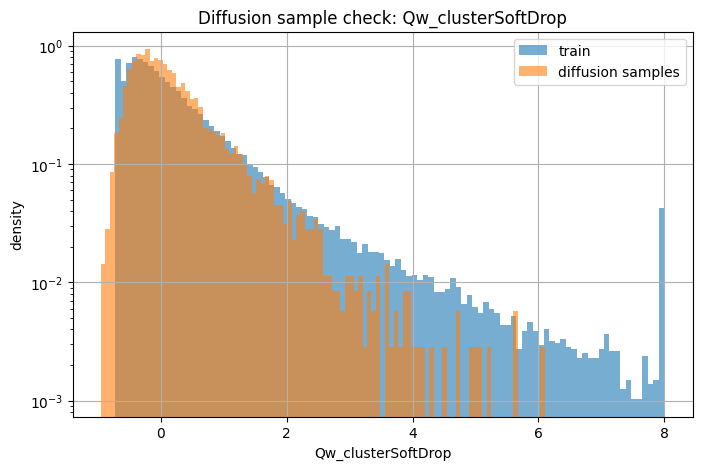

In [19]:
@torch.no_grad()
def sample_diffusion(model, n_samples, input_dim):
    model.eval()
    x = torch.randn(n_samples, input_dim, device=device)

    for t_int in reversed(range(T)):
        t = torch.full((n_samples,), t_int, device=device, dtype=torch.long)

        beta_t = betas[t].unsqueeze(1)
        alpha_t = alphas[t].unsqueeze(1)
        alpha_bar_t = alpha_bars[t].unsqueeze(1)

        eps_pred = model(x, t)

        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred
        )

        if t_int > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * noise
        else:
            x = mean

    return x.cpu().numpy()


n_samples = 5000
x_sampled = sample_diffusion(model, n_samples=n_samples, input_dim=input_dim)

print("sampled shape:", x_sampled.shape)
print("sampled finite:", np.isfinite(x_sampled).all())
print("sampled mean/std:", x_sampled.mean(), x_sampled.std())
print("sampled quantiles:", np.percentile(x_sampled.ravel(), [0, 1, 5, 25, 50, 75, 95, 99, 100]))

for i in range(min(5, input_dim)):
    plt.figure(figsize=(8, 5))
    plt.hist(A_train_norm[:, i], bins=100, density=True, alpha=0.6, label="train")
    plt.hist(x_sampled[:, i], bins=100, density=True, alpha=0.6, label="diffusion samples")
    plt.yscale("log")
    plt.xlabel(aggregate_feature_names[i])
    plt.ylabel("density")
    plt.title(f"Diffusion sample check: {aggregate_feature_names[i]}")
    plt.legend()
    plt.grid(True)
    plt.show()

## 20. Salvataggio

In [20]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": input_dim,
        "T": T,
        "beta_start": beta_start,
        "beta_end": beta_end,
        "time_emb_dim": time_emb_dim,
        "hidden_dim": hidden_dim,
        "n_blocks": n_blocks,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "aggregate_feature_names": aggregate_feature_names,
        "center": center,
        "scale": scale,
        "clip_value": CLIP_VALUE,
        "robust_scale": ROBUST_SCALE,
        "train_loss_history": train_loss_history,
        "val_loss_history": val_loss_history,
        "lr_history": lr_history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "score_results": score_results,
        "best_score_name": best_score_name,
        "best_auc_tuple": best_auc_tuple,
        "auc_train_bg": auc_train_bg,
        "best_auc_train_bg": best_auc_train_bg,
        "auc_logreg": auc_logreg,
        "auc_track_only_logreg": auc_track_only_logreg,
    },
    OUTPUT_DIR / "tabular_diffusion_v2_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "tabular_diffusion_v2_scores.npz",
    train_scores_t=train_scores_t,
    bg_scores_t=bg_scores_t,
    sig_scores_t=sig_scores_t,
    train_scores_t_z=train_scores_t_z,
    bg_scores_t_z=bg_scores_t_z,
    sig_scores_t_z=sig_scores_t_z,
    scores_bg_all=scores_bg_all,
    scores_sig_all=scores_sig_all,
    scores_bg_z_all=scores_bg_z_all,
    scores_sig_z_all=scores_sig_z_all,
    scores_bg_z_mid=scores_bg_z_mid,
    scores_sig_z_mid=scores_sig_z_mid,
    scores_bg_z_mid_high=scores_bg_z_mid_high,
    scores_sig_z_mid_high=scores_sig_z_mid_high,
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
    timesteps_all=timesteps_all.cpu().numpy(),
    best_score_name=np.array(best_score_name, dtype=object),
    best_auc=np.array(best_auc_tuple[2], dtype=np.float32),
    auc_train_bg=np.array(auc_train_bg, dtype=np.float32),
    best_auc_train_bg=np.array(best_auc_train_bg, dtype=np.float32),
    auc_logreg=np.array(auc_logreg, dtype=np.float32),
    auc_track_only_logreg=np.array(auc_track_only_logreg, dtype=np.float32),
)

config = {
    "dataset_name": DATASET_NAME,
    "processed_files": {k: str(v) for k, v in processed_files.items()},
    "EVAL_ONLY_TRUE_DISPLACED_SIGNAL": EVAL_ONLY_TRUE_DISPLACED_SIGNAL,
    "USE_JET_FEATURES": USE_JET_FEATURES,
    "USE_TRACK_AGGREGATES": USE_TRACK_AGGREGATES,
    "jet_features": jet_feature_names,
    "track_features": track_feature_names,
    "input_dim": int(input_dim),
    "robust_scale": bool(ROBUST_SCALE),
    "clip_value": float(CLIP_VALUE),
    "T": int(T),
    "beta_start": float(beta_start),
    "beta_end": float(beta_end),
    "time_emb_dim": int(time_emb_dim),
    "hidden_dim": int(hidden_dim),
    "n_blocks": int(n_blocks),
    "dropout": float(dropout),
    "learning_rate": float(learning_rate),
    "batch_size": int(batch_size),
    "n_epochs_requested": int(n_epochs),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "best_score_name": best_score_name,
    "best_auc": float(best_auc_tuple[2]),
    "best_auc_train_bg": float(best_auc_train_bg),
    "auc_logreg": float(auc_logreg),
    "auc_track_only_logreg": float(auc_track_only_logreg),
}

with open(OUTPUT_DIR / "tabular_diffusion_v2_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print(OUTPUT_DIR / "tabular_diffusion_v2_model.pt")
print(OUTPUT_DIR / "tabular_diffusion_v2_scores.npz")
print(OUTPUT_DIR / "tabular_diffusion_v2_config.json")

Saved:
outputs_diffusion_v2\tabular_diffusion_v2_model.pt
outputs_diffusion_v2\tabular_diffusion_v2_scores.npz
outputs_diffusion_v2\tabular_diffusion_v2_config.json


## Interpretazione

Nel run precedente il diffusion model era già sano:

- `train vs test background AUC ≈ 0.50`, molto buono;
- AUC signal/background circa `0.76`;
- timestep medi erano più informativi.

Questa versione prova a migliorare l'uso dello score:

- `raw_*` = denoising error medio;
- `z_*` = denoising error normalizzato per timestep rispetto al train background;
- `mid` = timestep medi, che nel run precedente erano i più utili;
- `mid_high` = timestep medi + alti.

Se il modello funziona bene, vuoi vedere:

1. AUC signal/background più alta del run precedente;
2. train-vs-test-background ancora vicino a 0.5;
3. sampling con scale finite e non assurde.